# 11. Topic Modeling: Themes in the Abstract Corpus

This notebook moves from entities to themes. Where notebooks 08 to 10 asked which diseases and chemicals appear, this asks what each abstract is about, learning the latent topics that organise the corpus and tracking how they shift over time.

It uses Latent Dirichlet Allocation (LDA), a classic, interpretable topic model that runs on the CPU with no model downloads. Abstracts are vectorised as word counts, LDA learns topics as word distributions, and each article gets a topic mixture. From there the notebook shows the topics, validates the topic count, assigns articles, tracks topics over time with a significance test, links topics back to the disease entities from notebook 09, and offers an optional interactive map and an optional embedding-based comparison.

A RUN_SCOPE switch controls cost: a sample for fast iteration, the full corpus for the final run. The fitted model and all tables cache to `data/4_topics/`, so reopening loads instead of recomputing.

Note on GPU: scikit-learn's LDA is CPU-only and cannot use CUDA, and the full corpus fits in roughly 20 minutes on CPU, so there is no reason to move it. The only GPU step here is the optional BERTopic comparison at the end, whose embeddings run on the GPU.

## Setup

In [ ]:
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

ROOT = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT, "data", "2_clean")
OUT_DIR = os.path.join(ROOT, "data", "4_topics")
os.makedirs(OUT_DIR, exist_ok=True)

# RUN_SCOPE: "sample" for a fast test run, "full" for the whole corpus.
RUN_SCOPE = "full"
SAMPLE_N = 100_000          # used when RUN_SCOPE == "sample"
N_TOPICS = 16               # number of topics to learn (tune to taste)

df = pd.read_parquet(DATA_DIR, columns=["uid", "year", "abstract"])
df = df[df["year"] <= 2025].copy()
df = df[df["abstract"].fillna("").str.len() > 0].copy()   # need text
print(f"loaded {len(df):,} abstract-bearing records")

if RUN_SCOPE == "sample":
    work = df.sample(min(SAMPLE_N, len(df)), random_state=42).copy()
    TAG = f"sample_{len(work)}"
    print(f"RUN_SCOPE = sample: modeling {len(work):,} abstracts")
else:
    work = df
    TAG = "full"
    print(f"RUN_SCOPE = full: modeling all {len(work):,} abstracts (slower)")

c:\Users\Maciej20090017\miniconda3\envs\ner\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded 3,063,120 abstract-bearing records
RUN_SCOPE = full: modeling all 3,063,120 abstracts (slower)


## 1. Vectorise the abstracts

Each abstract becomes a vector of word counts. The vectoriser drops English stopwords plus domain boilerplate, removes terms that are too rare (`min_df`) or too common (`max_df`), and caps the vocabulary. Counts, not TF-IDF: LDA needs counts.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# domain stopwords: generic research boilerplate that is not topical
EXTRA_STOP = {
    "study", "studies", "results", "methods", "conclusion", "conclusions", "background",
    "objective", "objectives", "patients", "patient", "analysis", "data", "using", "used",
    "show", "shown", "found", "report", "reported", "associated", "significant", "significantly",
    "compared", "group", "groups", "based", "result", "aim", "aims", "method",
    "however", "may", "also", "two", "one", "three", "high", "low", "increased", "decreased",
    "effect", "association", "associated", "result", "significant" # new additions 
}
STOP = list(ENGLISH_STOP_WORDS | EXTRA_STOP)

vectorizer = CountVectorizer(
    max_df=0.3,                 # drop terms in >30% of docs (boilerplate)
    min_df=25,                  # drop terms in <25 docs (noise)
    max_features=15000,          # vocabulary cap
    stop_words=STOP,
    token_pattern=r"(?u)\b[a-z][a-z]+\b",   # alphabetic words, length >= 2, lowercased
    ngram_range=(1, 2),       # uncomment for bigrams (breast cancer, heart failure); requires refitting LDA
)

X = vectorizer.fit_transform(tqdm(work["abstract"], desc="vectorizing"))
vocab = vectorizer.get_feature_names_out()
print(f"document-term matrix: {X.shape[0]:,} docs x {X.shape[1]:,} terms")

vectorizing: 100%|██████████| 3063120/3063120 [06:07<00:00, 8336.74it/s] 


document-term matrix: 3,063,120 docs x 15,000 terms


**What this shows.** The corpus is now a sparse document-term matrix. The frequency filters remove methodological boilerplate that would otherwise form meaningless topics, and the vocabulary cap keeps the model tractable. To capture multi-word terms like breast cancer or heart failure as single tokens, set `ngram_range=(1, 2)` on the vectoriser; that changes the vocabulary and requires refitting the LDA model below.

## 2. Fit the LDA topic model

LDA learns `N_TOPICS` topics, each a distribution over words, and represents every document as a mixture of topics. Fitting runs one pass at a time so the progress bar shows an ETA, and the model is cached. Perplexity is scored on a subsample so the diagnostic does not add a full extra pass over the corpus.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
import joblib, time

MAX_ITER = 30            # passes over the data; raise for better convergence
EVAL_SUBSAMPLE = 50_000  # docs used to estimate perplexity (full X is slow on the corpus)

model_path = os.path.join(OUT_DIR, f"lda_{TAG}_{N_TOPICS}_{X.shape[1]}feat.joblib")
if os.path.exists(model_path):
    lda = joblib.load(model_path)
    print(f"loaded cached LDA model: {model_path}")
else:
    lda = LatentDirichletAllocation(
        n_components=N_TOPICS, random_state=42,
        learning_method="online", batch_size=4096, n_jobs=-1,
        total_samples=X.shape[0],   # correct online scaling for the real corpus size
    )
    t0 = time.perf_counter()
    for _ in tqdm(range(MAX_ITER), desc=f"LDA {N_TOPICS} topics", unit="pass"):
        lda.partial_fit(X)
    print(f"fit in {time.perf_counter() - t0:,.0f}s")
    joblib.dump(lda, model_path)
    print(f"cached LDA model to {model_path}")

# perplexity on a subsample so this line does not trigger a full extra pass
idx = np.random.RandomState(0).choice(X.shape[0], min(EVAL_SUBSAMPLE, X.shape[0]), replace=False)
print(f"topics: {lda.n_components}, perplexity on {len(idx):,} docs (lower is better): {lda.perplexity(X[idx]):.0f}")

LDA 16 topics: 100%|██████████| 30/30 [41:40<00:00, 83.36s/pass] 


fit in 2,501s
cached LDA model to e:\01_PROJECTS\01_GitHub\01_active\biomedical-literature-analysis\data\4_topics\lda_full_16_15000feat.joblib
topics: 16, perplexity on 50,000 docs (lower is better): 3178


**What this shows.** A fitted model and a perplexity score. Perplexity is only meaningful for comparison across runs on the same data and seed; on its own the number means little, and it tends to keep dropping as topics increase even past the point of interpretability. Use the coherence sweep below to choose the topic count, not perplexity alone.

## 3. The discovered topics

Each topic is summarised by its highest-probability words. Reading these gives the theme. Topic numbers are arbitrary labels.

In [ ]:
def top_words(model, feature_names, n=12):
    rows = []
    for k, comp in enumerate(model.components_):
        words = [feature_names[i] for i in comp.argsort()[-n:][::-1]]
        rows.append({"topic": k, "top_words": ", ".join(words)})
    return pd.DataFrame(rows)

topics_df = top_words(lda, vocab, n=12)
topics_df.to_parquet(os.path.join(OUT_DIR, f"topics_words_{TAG}_{N_TOPICS}.parquet"))
for _, r in topics_df.iterrows():
    print(f"topic {r['topic']:>2}: {r['top_words']}")

topic  0: ci, risk, cancer, years, mortality, survival, vs, age, outcomes, cohort, higher, rates
topic  1: cells, cell, cancer, tumor, immune, hiv, il, human, expression, infection, virus, anti
topic  2: brain, cognitive, ad, memory, subjects, task, motor, visual, performance, control, function, functional
topic  3: cells, protein, cell, activity, receptor, human, induced, signaling, activation, expression, binding, role
topic  4: imaging, ct, mm, injury, mri, bone, injuries, magnetic, knee, resonance, tomography, magnetic resonance
topic  5: model, time, test, models, different, sensitivity, samples, performance, accuracy, detection, human, values
topic  6: health, care, medical, research, use, community, program, intervention, survey, participants, practice, education
topic  7: blood, exposure, pressure, infants, pregnancy, respiratory, pd, maternal, smoking, lung, birth, pulmonary
topic  8: gene, genes, dna, expression, genetic, human, protein, mutations, identified, rna, proteins, 

**What this shows.** The corpus's latent themes, read from each topic's top words. Coherent word lists (anatomy plus disease plus method) are interpretable topics; a few may be vaguer or mixed, which is normal for LDA. These are data-driven, not pre-specified.

In [ ]:
# human-readable topic labels (edit to match your top words + enrichment)
TOPIC_LABELS = {
    0: "Cancer biology & therapy",
    1: "Disease mechanisms & reviews",
    2: "Neuroscience & cognition",
    3: "Cancer epidemiology & screening",
    4: "Surgery & complications",
    5: "Cardiometabolic & blood",
    6: "Clinical trials & drug therapy",
    7: "Cell & molecular biology",
    8: "Health services & public health",
    9: "Cardiovascular outcomes",
    10: "Mental health",
    11: "Genetics & genomics",
    12: "Infectious disease",
    13: "Imaging & diagnostic modeling",
    14: "Epidemiology & risk factors",
}
topics_df["label"] = topics_df["topic"].map(TOPIC_LABELS)
topics_df.to_parquet(os.path.join(OUT_DIR, f"topics_labeled_{TAG}_{N_TOPICS}.parquet"))

## 4. Choosing the topic count

This sweeps several candidate topic counts and scores each with C_v coherence, which tracks human interpretability far better than perplexity. It refits a small LDA per candidate on a sample, so it is quick. Set `RUN_COHERENCE` to run it. If the peak is near the current `N_TOPICS`, that justifies the choice; if not, change `N_TOPICS` and refit. Requires `gensim`.

coherence sweep: 100%|██████████| 6/6 [04:37<00:00, 46.23s/K]


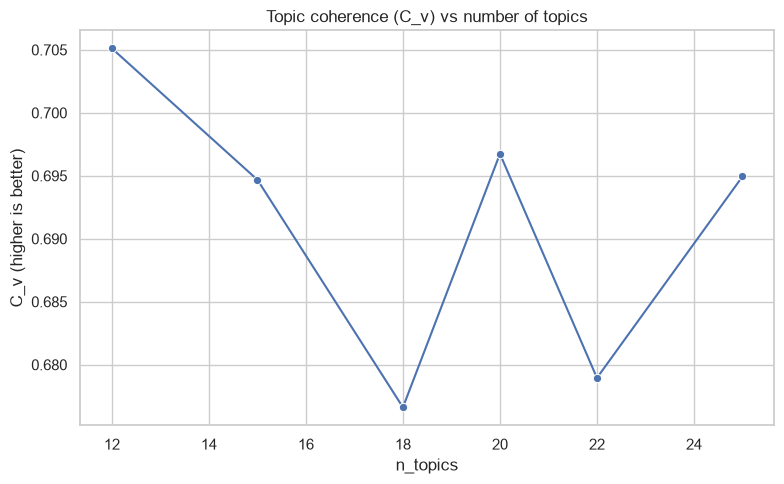

  K=12: C_v = 0.705
  K=15: C_v = 0.695
  K=18: C_v = 0.677
  K=20: C_v = 0.697
  K=22: C_v = 0.679
  K=25: C_v = 0.695


In [ ]:
RUN_COHERENCE = True   # set True to sweep candidate topic counts (needs gensim)

if RUN_COHERENCE:
    from sklearn.decomposition import LatentDirichletAllocation
    from gensim.corpora import Dictionary
    from gensim.models import CoherenceModel

    COH_SAMPLE = 20_000
    #Ks = [10, 15, 20, 25, 30]
    Ks = [12, 15, 18, 20, 22, 25]

    cidx = np.random.RandomState(0).choice(X.shape[0], min(COH_SAMPLE, X.shape[0]), replace=False)
    Xc = X[cidx]
    analyzer = vectorizer.build_analyzer()
    texts = [analyzer(a) for a in work["abstract"].iloc[cidx].tolist()]
    gdict = Dictionary(texts)

    def _topwords(model, n=15):
        return [[vocab[i] for i in comp.argsort()[-n:][::-1]] for comp in model.components_]

    coh = []
    for k in tqdm(Ks, desc="coherence sweep", unit="K"):
        m = LatentDirichletAllocation(n_components=k, random_state=42,
                                      learning_method="batch", max_iter=15, n_jobs=-1)
        m.fit(Xc)
        cm = CoherenceModel(topics=_topwords(m), texts=texts, dictionary=gdict, coherence="c_v")
        coh.append(cm.get_coherence())

    plt.figure(figsize=(8, 5))
    sns.lineplot(x=Ks, y=coh, marker="o")
    plt.title("Topic coherence (C_v) vs number of topics")
    plt.xlabel("n_topics"); plt.ylabel("C_v (higher is better)")
    plt.tight_layout(); plt.show()
    for k, c in zip(Ks, coh):
        print(f"  K={k:>2}: C_v = {c:.3f}")
else:
    print("RUN_COHERENCE = False (skipping topic-count sweep)")

**What this shows.** Coherence as a function of topic count. The peak is the data-driven sweet spot. Coherence often plateaus rather than spiking, so prefer the smallest count near the top, which keeps topics broad and readable. This is a model-selection step: it does not change the fitted model unless you act on it.

## 5. Topic similarity

Cosine similarity between the topic-word distributions shows which topics overlap. Bright off-diagonal cells flag redundant topics that could be merged by lowering the topic count.

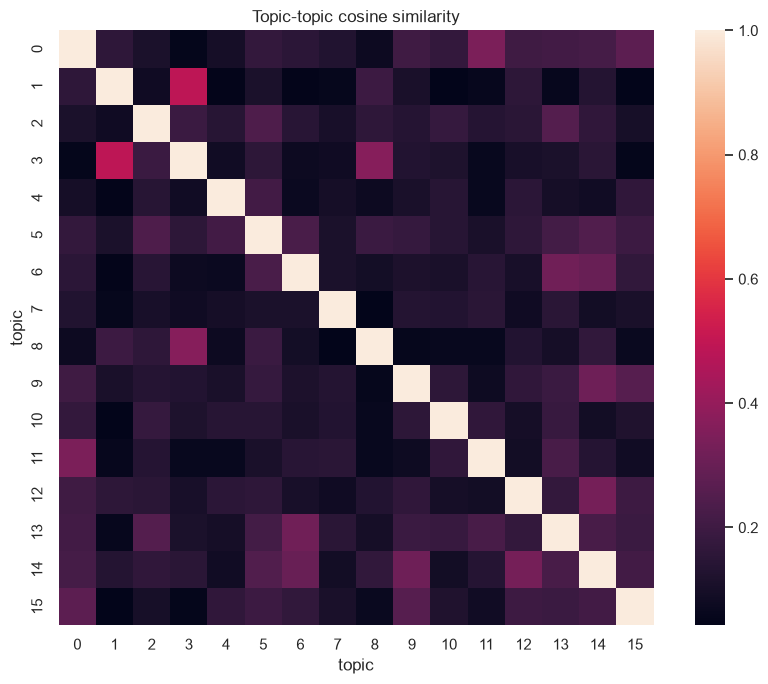

most similar topic pairs (cosine > 0.3):
  topic 1 ~ topic 3: 0.49  |  cells / cells
  topic 3 ~ topic 8: 0.37  |  cells / gene
  topic 0 ~ topic 11: 0.34  |  ci / women
  topic 12 ~ topic 14: 0.33  |  disease / review
  topic 6 ~ topic 13: 0.32  |  health / children
  topic 9 ~ topic 14: 0.31  |  treatment / review


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(lda.components_)
plt.figure(figsize=(9, 7))
sns.heatmap(sim, cmap="rocket", square=True,
            xticklabels=range(N_TOPICS), yticklabels=range(N_TOPICS))
plt.title("Topic-topic cosine similarity"); plt.xlabel("topic"); plt.ylabel("topic")
plt.tight_layout(); plt.show()

pairs = [(i, j, sim[i, j]) for i in range(N_TOPICS) for j in range(i + 1, N_TOPICS) if sim[i, j] > 0.3]
print("most similar topic pairs (cosine > 0.3):")
for i, j, s in sorted(pairs, key=lambda t: -t[2]):
    print(f"  topic {i} ~ topic {j}: {s:.2f}  |  {topics_df.loc[i,'top_words'].split(', ')[0]} / {topics_df.loc[j,'top_words'].split(', ')[0]}")
if not pairs:
    print("  none above 0.3 (topics are well separated)")

**What this shows.** How distinct the topics are. A near-empty off-diagonal means well-separated themes; a bright block of two or three topics signals redundancy and is a reason to rerun with fewer topics. The listed pairs above the threshold are the candidates to inspect.

## 6. Assign topics to articles and size them

Each article is assigned its dominant topic (the highest-weight topic in its mixture). The transform runs in batches so it shows progress and an ETA, and both the per-article assignment and the full topic-mixture matrix are saved for downstream use.

transform: 100%|██████████| 62/62 [01:05<00:00,  1.05s/batch]


transform done in 65.3s


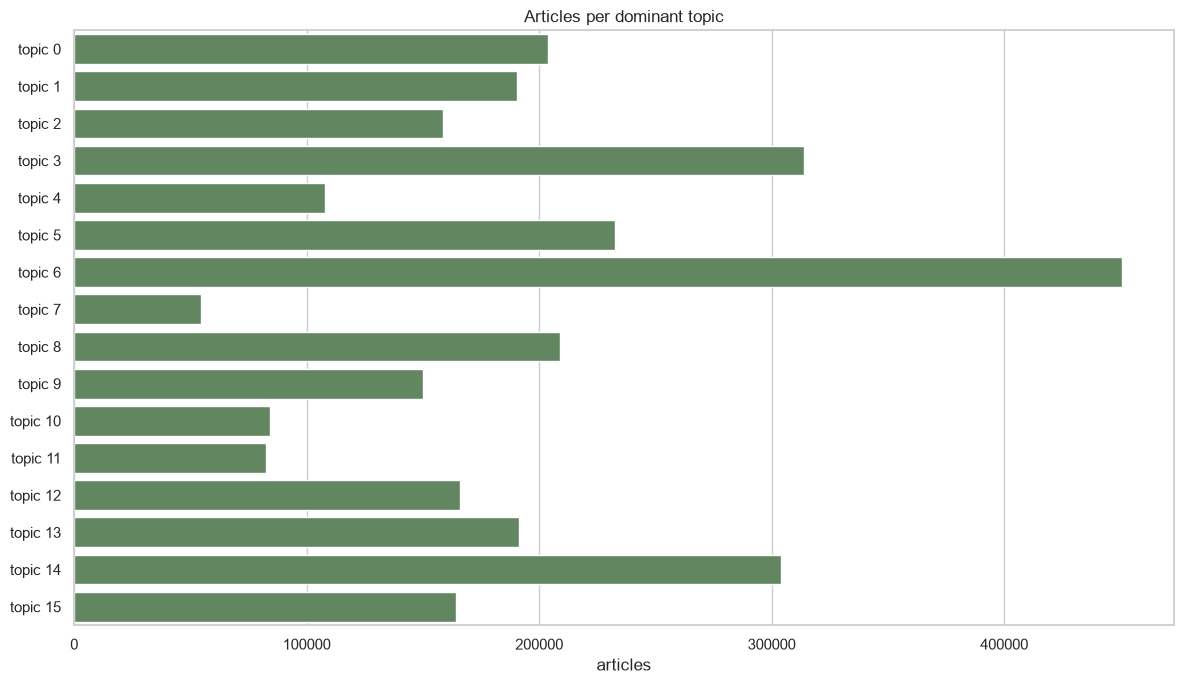

largest topics:
  topic 6 (450,511 articles): health, care, medical, research, use, community, program, intervention, survey, participants, practice, education
  topic 3 (313,753 articles): cells, protein, cell, activity, receptor, human, induced, signaling, activation, expression, binding, role
  topic 14 (304,203 articles): review, clinical, treatment, disease, research, evidence, recent, development, new, use, potential, therapy
  topic 5 (232,457 articles): model, time, test, models, different, sensitivity, samples, performance, accuracy, detection, human, values
  topic 8 (209,021 articles): gene, genes, dna, expression, genetic, human, protein, mutations, identified, rna, proteins, variants


In [ ]:
import time

# document-topic weights, transformed in batches for a progress bar + ETA
BATCH = 50_000
n = X.shape[0]
doc_topic = np.empty((n, lda.n_components), dtype=np.float32)
t0 = time.perf_counter()
for i in tqdm(range(0, n, BATCH), desc="transform", unit="batch"):
    doc_topic[i:i + BATCH] = lda.transform(X[i:i + BATCH])
print(f"transform done in {time.perf_counter() - t0:,.1f}s")

work = work.copy()
work["dominant_topic"] = doc_topic.argmax(axis=1)
work["topic_weight"] = doc_topic.max(axis=1)

# save the per-article assignment and the full mixture matrix (reusable)
assign = work[["uid", "year", "dominant_topic", "topic_weight"]].copy()
assign.to_parquet(os.path.join(OUT_DIR, f"article_topics_{TAG}_{N_TOPICS}.parquet"))
np.save(os.path.join(OUT_DIR, f"doc_topic_{TAG}_{N_TOPICS}.npy"), doc_topic)

sizes = work["dominant_topic"].value_counts().sort_index()
plt.figure(figsize=(12, 7))
sns.barplot(x=sizes.values, y=[f"topic {k}" for k in sizes.index], color="#5b8c5a")
plt.title("Articles per dominant topic"); plt.xlabel("articles"); plt.ylabel("")
plt.tight_layout(); plt.show()
print("largest topics:")
for k in sizes.sort_values(ascending=False).head(5).index:
    print(f"  topic {k} ({sizes[k]:,} articles): {topics_df.loc[k, 'top_words']}")

**What this shows.** The relative size of each theme by how many articles it dominates. Large topics are the corpus's major research areas; small ones are niche. The full mixture matrix is saved alongside the dominant-topic assignment, so later work can use soft (multi-topic) membership rather than the single dominant label.

## 7. Topics over time

The share of each topic per year shows which themes are rising or falling, the thematic counterpart to the entity trends in notebook 10.

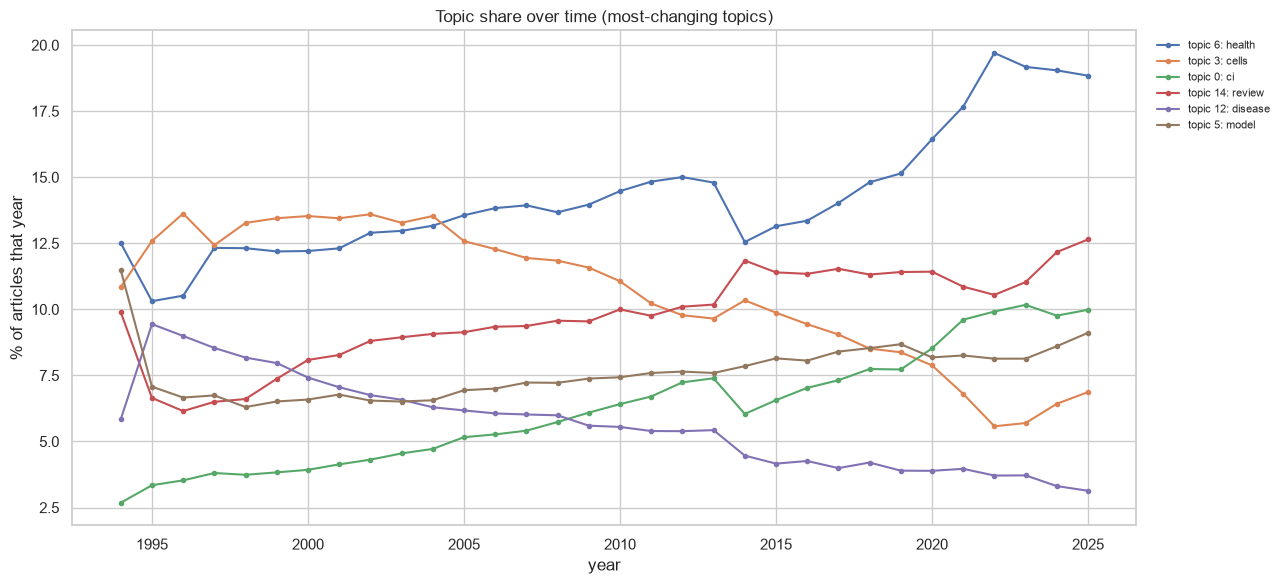

most-changing topics (share range):
  topic 6: health, care, medical, research, use, community, program, intervention, survey, participants, practice, education
  topic 3: cells, protein, cell, activity, receptor, human, induced, signaling, activation, expression, binding, role
  topic 0: ci, risk, cancer, years, mortality, survival, vs, age, outcomes, cohort, higher, rates
  topic 14: review, clinical, treatment, disease, research, evidence, recent, development, new, use, potential, therapy
  topic 12: disease, cases, diagnosis, case, clinical, tumor, tumors, lesions, syndrome, rare, features, biopsy
  topic 5: model, time, test, models, different, sensitivity, samples, performance, accuracy, detection, human, values


In [ ]:
year_topic = (work.groupby(["year", "dominant_topic"]).size()
              .unstack(fill_value=0))
year_topic_share = year_topic.div(year_topic.sum(axis=1), axis=0) * 100
year_topic_share.to_parquet(os.path.join(OUT_DIR, f"topic_timeline_{TAG}_{N_TOPICS}.parquet"))

# plot the topics that changed most (largest range in share)
volatility = (year_topic_share.max() - year_topic_share.min()).sort_values(ascending=False)
movers = volatility.head(6).index
plt.figure(figsize=(13, 6))
for k in movers:
    plt.plot(year_topic_share.index, year_topic_share[k], marker="o", markersize=3,
             label=f"topic {k}: {topics_df.loc[k, 'top_words'].split(', ')[0]}")
plt.title("Topic share over time (most-changing topics)")
plt.xlabel("year"); plt.ylabel("% of articles that year")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
print("most-changing topics (share range):")
for k in movers:
    print(f"  topic {k}: {topics_df.loc[k, 'top_words']}")

**What this shows.** The themes whose prevalence shifted most over time. Because topics are mixtures of words rather than single terms, this captures thematic movement that entity counts alone would miss. The next cell tests these movements for significance rather than reading them by eye.

## 8. Which trends are significant

The Kendall tau rank-correlation test checks each topic's yearly share against time, turning a visual impression of rising or falling into a tested claim with a p-value.

In [ ]:
from scipy.stats import kendalltau

share = year_topic_share   # rows = year, columns = topic, values = % share
print("significant topic trends (p < 0.05):")
any_sig = False
for k in share.columns:
    tau, p = kendalltau(share.index.values, share[k].values)
    if p < 0.05:
        any_sig = True
        direction = "rising" if tau > 0 else "falling"
        print(f"  topic {k:>2}: {direction:<7} (tau={tau:+.2f}, p={p:.3f})  {topics_df.loc[k, 'top_words']}")
if not any_sig:
    print("  no topic trend reached p < 0.05")

significant topic trends (p < 0.05):
  topic  0: rising  (tau=+0.94, p=0.000)  ci, risk, cancer, years, mortality, survival, vs, age, outcomes, cohort, higher, rates
  topic  1: falling (tau=-0.39, p=0.001)  cells, cell, cancer, tumor, immune, hiv, il, human, expression, infection, virus, anti
  topic  2: rising  (tau=+0.29, p=0.018)  brain, cognitive, ad, memory, subjects, task, motor, visual, performance, control, function, functional
  topic  3: falling (tau=-0.77, p=0.000)  cells, protein, cell, activity, receptor, human, induced, signaling, activation, expression, binding, role
  topic  4: falling (tau=-0.88, p=0.000)  imaging, ct, mm, injury, mri, bone, injuries, magnetic, knee, resonance, tomography, magnetic resonance
  topic  5: rising  (tau=+0.66, p=0.000)  model, time, test, models, different, sensitivity, samples, performance, accuracy, detection, human, values
  topic  6: rising  (tau=+0.75, p=0.000)  health, care, medical, research, use, community, program, intervention, 

**What this shows.** The topics whose share has a statistically significant monotonic trend. A positive tau is rising, a negative tau is falling, and the p-value guards against reading noise as a trend. This is a more defensible basis for a rising-or-falling claim than the line plot alone.

## 9. Topic prevalence by era

The EDA defined three eras (pre-2010, 2010-19, 2020+). This shows how each topic's share differs within each era and which themes shifted most from the earliest era to the most recent, complementing the year-by-year trend test above.

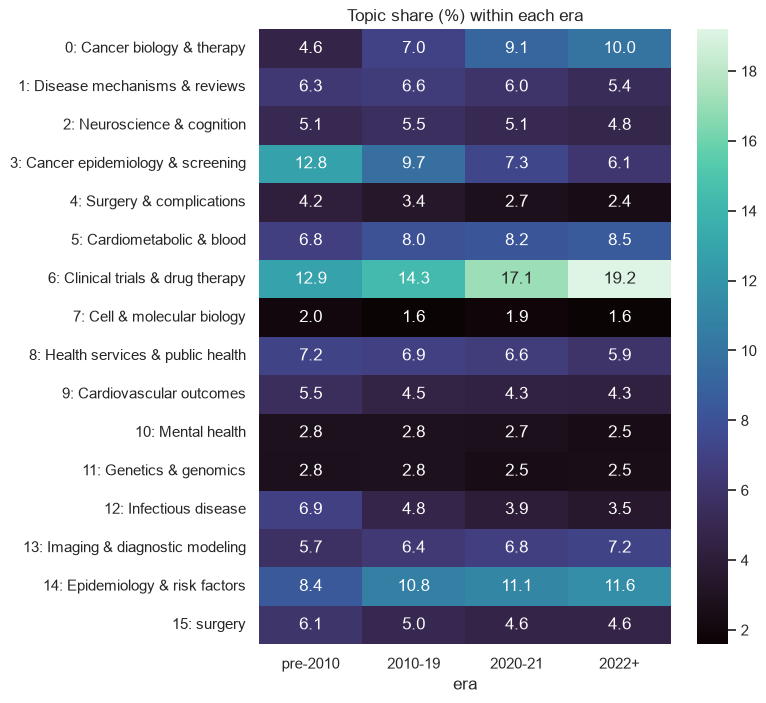

largest share change, pre-2010 to 2022+ (percentage points):
  topic  3 [Cancer epidemiology & screening]: -6.6 pp  (12.8 -> 6.1)
  topic 12 [Infectious disease]: -3.5 pp  (6.9 -> 3.5)
  topic  4 [Surgery & complications]: -1.8 pp  (4.2 -> 2.4)
  topic 15 [surgery]: -1.5 pp  (6.1 -> 4.6)
  topic  5 [Cardiometabolic & blood]: +1.7 pp  (6.8 -> 8.5)
  topic 14 [Epidemiology & risk factors]: +3.2 pp  (8.4 -> 11.6)
  topic  0 [Cancer biology & therapy]: +5.3 pp  (4.6 -> 10.0)
  topic  6 [Clinical trials & drug therapy]: +6.3 pp  (12.9 -> 19.2)


In [ ]:
# topic prevalence by era (COVID window split out: pre-2010, 2010-19, 2020-21, 2022+)
era = pd.cut(assign["year"], [0, 2009, 2019, 2021, 2100],
             labels=["pre-2010", "2010-19", "2020-21", "2022+"])
era_topic = (assign.assign(era=era)
             .groupby(["era", "dominant_topic"], observed=True).size().unstack(fill_value=0))
era_share = era_topic.div(era_topic.sum(axis=1), axis=0) * 100   # % within each era
era_share.to_parquet(os.path.join(OUT_DIR, f"topic_by_era_{TAG}_{N_TOPICS}.parquet"))

lab = {k: TOPIC_LABELS.get(k, topics_df.loc[k, "top_words"].split(", ")[0]) for k in range(N_TOPICS)}
plt.figure(figsize=(8, max(6, N_TOPICS * 0.45)))
sns.heatmap(era_share.T, annot=True, fmt=".1f", cmap="mako",
            yticklabels=[f"{k}: {lab[k]}" for k in era_share.columns])
plt.title("Topic share (%) within each era"); plt.xlabel("era"); plt.ylabel("")
plt.tight_layout(); plt.show()

delta = (era_share.loc["2022+"] - era_share.loc["pre-2010"]).sort_values()
print("largest share change, pre-2010 to 2022+ (percentage points):")
for k in list(delta.index[:4]) + list(delta.index[-4:]):
    print(f"  topic {k:>2} [{lab[k]}]: {delta[k]:+.1f} pp  ({era_share.loc['pre-2010', k]:.1f} -> {era_share.loc['2022+', k]:.1f})")

**What this shows.** Each topic's prevalence inside each era, and the topics that moved most between the first and last era. Reading by era rather than by single year smooths the 2013 to 2015 indexing dip noted in the EDA and matches the segmentation used elsewhere in the project. Rising and falling here should agree with the Kendall test above; the era view adds the size of each shift in percentage points.

## 10. Topics and diseases together

Cross-referencing the topic assignment with the disease entities from notebook 09 links the two views: which diseases concentrate in which topics. It searches `data/3_entities` for an entity table, prefers the dictionary one, and skips cleanly if none is present.

In [ ]:
from collections import Counter

# find an entity table from notebook 09 (prefer the dictionary one)
ent_dir = os.path.join(ROOT, "data", "3_entities")
cands = ([os.path.join(ent_dir, "article_entities_dictionary.parquet")]
         + sorted(glob.glob(os.path.join(ent_dir, "article_entities_*.parquet"))))
ent_path = next((p for p in cands if os.path.exists(p)), None)

if ent_path is None:
    print("entity table not found in data/3_entities; run notebook 09 first to enable this cross-reference.")
else:
    ent = pd.read_parquet(ent_path)
    dz_col = next((c for c in ["dz_dict", "dz_model", "diseases", "dz"] if c in ent.columns), None)
    if dz_col is None:
        print(f"loaded {os.path.basename(ent_path)} but found no disease column; columns: {list(ent.columns)}")
    else:
        merged = assign.merge(ent[["uid", dz_col]], on="uid", how="inner")

        # corpus-wide disease frequency = baseline for enrichment
        base = Counter(d for lst in merged[dz_col] for d in (lst if lst is not None else []))
        base_total = sum(base.values())
        print(f"cross-referencing with {os.path.basename(ent_path)} (column '{dz_col}'), {len(merged):,} matched articles")
        print("most enriched diseases per topic (over-represented vs corpus baseline; xN = fold enrichment):")
        for k in sizes.sort_values(ascending=False).index:
            sub = merged[merged["dominant_topic"] == k]
            cnt = Counter(d for lst in sub[dz_col] for d in (lst if lst is not None else []))
            tot = sum(cnt.values()) or 1
            lift = {d: (cnt[d] / tot) / (base[d] / base_total)
                    for d in cnt if cnt[d] >= 10 and base[d] >= 50}
            top = sorted(lift, key=lift.get, reverse=True)[:5]
            shown = ", ".join(f"{d} (x{lift[d]:.1f})" for d in top) or "(none)"
            print(f"  topic {k:>2} [{topics_df.loc[k, 'top_words'].split(', ')[0]}]: {shown}")

cross-referencing with article_entities_dictionary.parquet (column 'dz_dict'), 3,063,120 matched articles
most enriched diseases per topic (over-represented vs corpus baseline; xN = fold enrichment):
  topic  6 [health]: covid-19 (x4.6), covid (x4.1), hiv (x2.5), influenza (x2.5), tuberculosis (x1.8)
  topic  3 [cells]: inflammation (x3.3), fibrosis (x2.7), alzheimer's disease (x2.6), alzheimer (x2.2), parkinson (x1.8)
  topic 14 [review]: cardiovascular disease (x1.7), pneumonia (x1.4), heart failure (x1.4), sepsis (x1.4), tuberculosis (x1.4)
  topic  5 [model]: sars-cov-2 (x2.7), tuberculosis (x2.1), lung cancer (x2.0), prostate cancer (x2.0), breast cancer (x1.6)
  topic  8 [gene]: sars-cov-2 (x3.2), leukemia (x2.4), influenza (x1.8), cancer (x1.6), schizophrenia (x1.6)
  topic  0 [ci]: myocardial infarction (x2.2), pneumonia (x2.1), breast cancer (x2.0), atrial fibrillation (x1.9), lung cancer (x1.9)
  topic 13 [children]: ptsd (x9.8), anxiety (x7.5), depression (x6.8), adhd (x6.1)

**What this shows.** The bridge between themes and entities, ranked by enrichment rather than raw count, so each topic shows the diseases that are distinctively over-represented in it rather than just the corpus-wide leaders. A value like x2.5 means the disease is 2.5 times more concentrated in that topic than across the corpus. Where a topic's words and its enriched diseases agree, the theme is well-defined. This requires notebook 09 to have produced an entity table in `data/3_entities`.

## 11. Interactive topic map (optional)

pyLDAvis builds an interactive inter-topic distance map with a relevance slider, saved as a self-contained HTML file. It runs on a document subsample so it stays responsive. Set `RUN_LDAVIS` to build it. Requires `pyldavis` (3.4+ API: `pyLDAvis.lda_model.prepare`).

In [ ]:
RUN_LDAVIS = True   # set True to build the interactive map (needs pyldavis)

if RUN_LDAVIS:
    import pyLDAvis
    import pyLDAvis.lda_model
    from IPython.display import display

    vidx = np.random.RandomState(0).choice(X.shape[0], min(20_000, X.shape[0]), replace=False)
    vis = pyLDAvis.lda_model.prepare(lda, X[vidx], vectorizer)
    html_path = os.path.join(OUT_DIR, f"ldavis_{TAG}_{N_TOPICS}.html")
    pyLDAvis.save_html(vis, html_path)
    print(f"saved {html_path}")
    display(pyLDAvis.display(vis))
else:
    print("RUN_LDAVIS = False (skipping interactive map)")

saved e:\01_PROJECTS\01_GitHub\01_active\biomedical-literature-analysis\data\4_topics\ldavis_full_16.html


**What this shows.** An interactive map: bubble size is topic prevalence, distance is topic similarity, and the relevance slider trades off word frequency against word exclusivity to reveal each topic's identity. The HTML is self-contained and shareable with people who do not run Python.

## 12. Embedding-based comparison (optional, GPU)

BERTopic embeds the abstracts with a sentence transformer, then clusters them, producing topics that often read more sharply than LDA's bag-of-words themes. The embedding step uses the GPU. This is a comparison model, not a replacement for the LDA tables above. Set `RUN_BERTOPIC` to run it. Requires `bertopic` and `sentence-transformers`.

In [ ]:
RUN_BERTOPIC = True   # set True for an embedding-based comparison (CPU here; torch has no CUDA)

if RUN_BERTOPIC:
    from sentence_transformers import SentenceTransformer
    from bertopic import BERTopic

    bidx = np.random.RandomState(0).choice(len(work), min(100_000, len(work)), replace=False)
    docs = work["abstract"].iloc[bidx].tolist()

    embedder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")   # torch is CPU-only in this env
    emb = embedder.encode(docs, batch_size=256, show_progress_bar=True, convert_to_numpy=True)

    bt = BERTopic(min_topic_size=100, verbose=True)          # fewer tiny noise topics
    btopics, bprobs = bt.fit_transform(docs, emb)
    new_topics = bt.reduce_outliers(docs, btopics)           # reassign most of the -1 pile
    bt.update_topics(docs, topics=new_topics)                # make the model reflect the reassignment
    bt.save(os.path.join(OUT_DIR, "bertopic_sample_100k"))
    print(bt.get_topic_info().head(20).to_string(index=False))
else:
    print("RUN_BERTOPIC = False (skipping embedding-based comparison)")

c:\Users\Maciej20090017\miniconda3\envs\ner\Lib\site-packages\spacy\cli\_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
Batches: 100%|██████████| 391/391 [19:32<00:00,  3.00s/it]
2026-07-01 12:34:09,497 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-01 12:34:31,518 - BERTopic - Dimensionality - Completed ✓
2026-07-01 12:34:31,519 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-01 12:34:36,556 - BERTopic - Cluster - Completed ✓
2026-07-01 12:34:36,566 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-01 12:34:44,435 - BERTopic - Representation - Completed ✓
100%|██████████| 46/46 [00:43<00:00,  1.07it/s]
2026-07-01 12:35:30,562 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used after

 Topic  Count                                         Name                                                                                                Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

**What this shows.** An alternative topic set from a modern embedding model, for comparison against LDA. BERTopic infers the number of topics and isolates outliers instead of forcing every document into a topic, so sizes and granularity will differ from the LDA results above.

## 13. Summary and caveats

### What this notebook produced and saved (in `data/4_topics/`)
The fitted LDA model, the topic-word table, the per-article dominant-topic assignment and the full topic-mixture matrix, and the topic timeline, all tagged by scope and topic count. Optional artifacts include the pyLDAvis HTML and a saved BERTopic model.

### How to run it at full scope
Set `RUN_SCOPE = "full"` and rerun. The sample run is for choosing `N_TOPICS` and checking the topics make sense; the full run produces the final model. Everything caches, so reopening loads rather than refits.

### Caveats
LDA topics are statistical word clusters, not curated categories: most are interpretable, but some are mixed or vague, and the topic count is a choice, not a discovered truth. Dominant-topic assignment hides that articles are mixtures, so the saved full matrix is the better basis for nuanced work. Results depend on the preprocessing and the random seed. Topic prevalence over time is subject to the same rising keyword-coverage and corpus-growth considerations noted in earlier notebooks. As elsewhere in the project, this covers abstracts only, within the filtered corpus.